# Week 2 - Distribution Fitting

Fits Normal, Exponential, Gamma, Lognormal, and Uniform distributions to each numeric column of the cleaned heart disease data, and picks the best fit by Kolmogorov-Smirnov p-value.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
from scipy import stats
from src.data_loader import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
loader = DataLoader()
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

# Re-apply categorical dtype (dtype doesn't survive a plain CSV round-trip)
for col in df.columns:
    if df[col].nunique() < 10:
        df[col] = df[col].astype('category')

print("=" * 60)
print("DISTRIBUTION FITTING")
print("=" * 60)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [2]:
# ==================== 1. FIT DISTRIBUTIONS ====================
def fit_distributions_to_column(data, column_name):
    """Fit multiple distributions to a column of data."""
    results = {}
    distributions = {
        'Normal': stats.norm,
        'Exponential': stats.expon,
        'Gamma': stats.gamma,
        'Lognormal': stats.lognorm,
        'Uniform': stats.uniform
    }

    for dist_name, dist in distributions.items():
        try:
            params = dist.fit(data)
            ks_stat, p_value = stats.kstest(data, dist_name.lower(), args=params)
            results[dist_name] = {
                'params': params,
                'ks_statistic': ks_stat,
                'p_value': p_value,
                'good_fit': p_value > 0.05
            }
        except Exception:
            results[dist_name] = {'error': 'Could not fit'}

    best_fit = None
    best_p = -1
    for dist_name, result in results.items():
        if 'p_value' in result and result['p_value'] > best_p:
            best_p = result['p_value']
            best_fit = dist_name

    return results, best_fit, best_p

# Fit distributions to each numeric column
all_fitting_results = {}
for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 10:  # Need enough data
        results, best_fit, best_p = fit_distributions_to_column(data, col)
        all_fitting_results[col] = {'results': results, 'best_fit': best_fit, 'best_p_value': best_p}
        print(f"\nColumn: {col}")
        print(f"  Best fitting distribution: {best_fit}")
        print(f"  p-value: {best_p:.4f}")
        print(f"  Good fit: {'Yes' if best_p > 0.05 else 'No'}")


Column: age
  Best fitting distribution: Gamma
  p-value: 0.0310
  Good fit: No

Column: trestbps
  Best fitting distribution: Gamma
  p-value: 0.1546
  Good fit: Yes

Column: chol
  Best fitting distribution: Gamma
  p-value: 0.9773
  Good fit: Yes

Column: thalach
  Best fitting distribution: Gamma
  p-value: 0.0371
  Good fit: No
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6941: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)

Column: oldpeak
  Best fitting distribution: Uniform
  p-value: 0.0000
  Good fit: No
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)

Column: hr_reserve
  Best fitting distribution: Gam

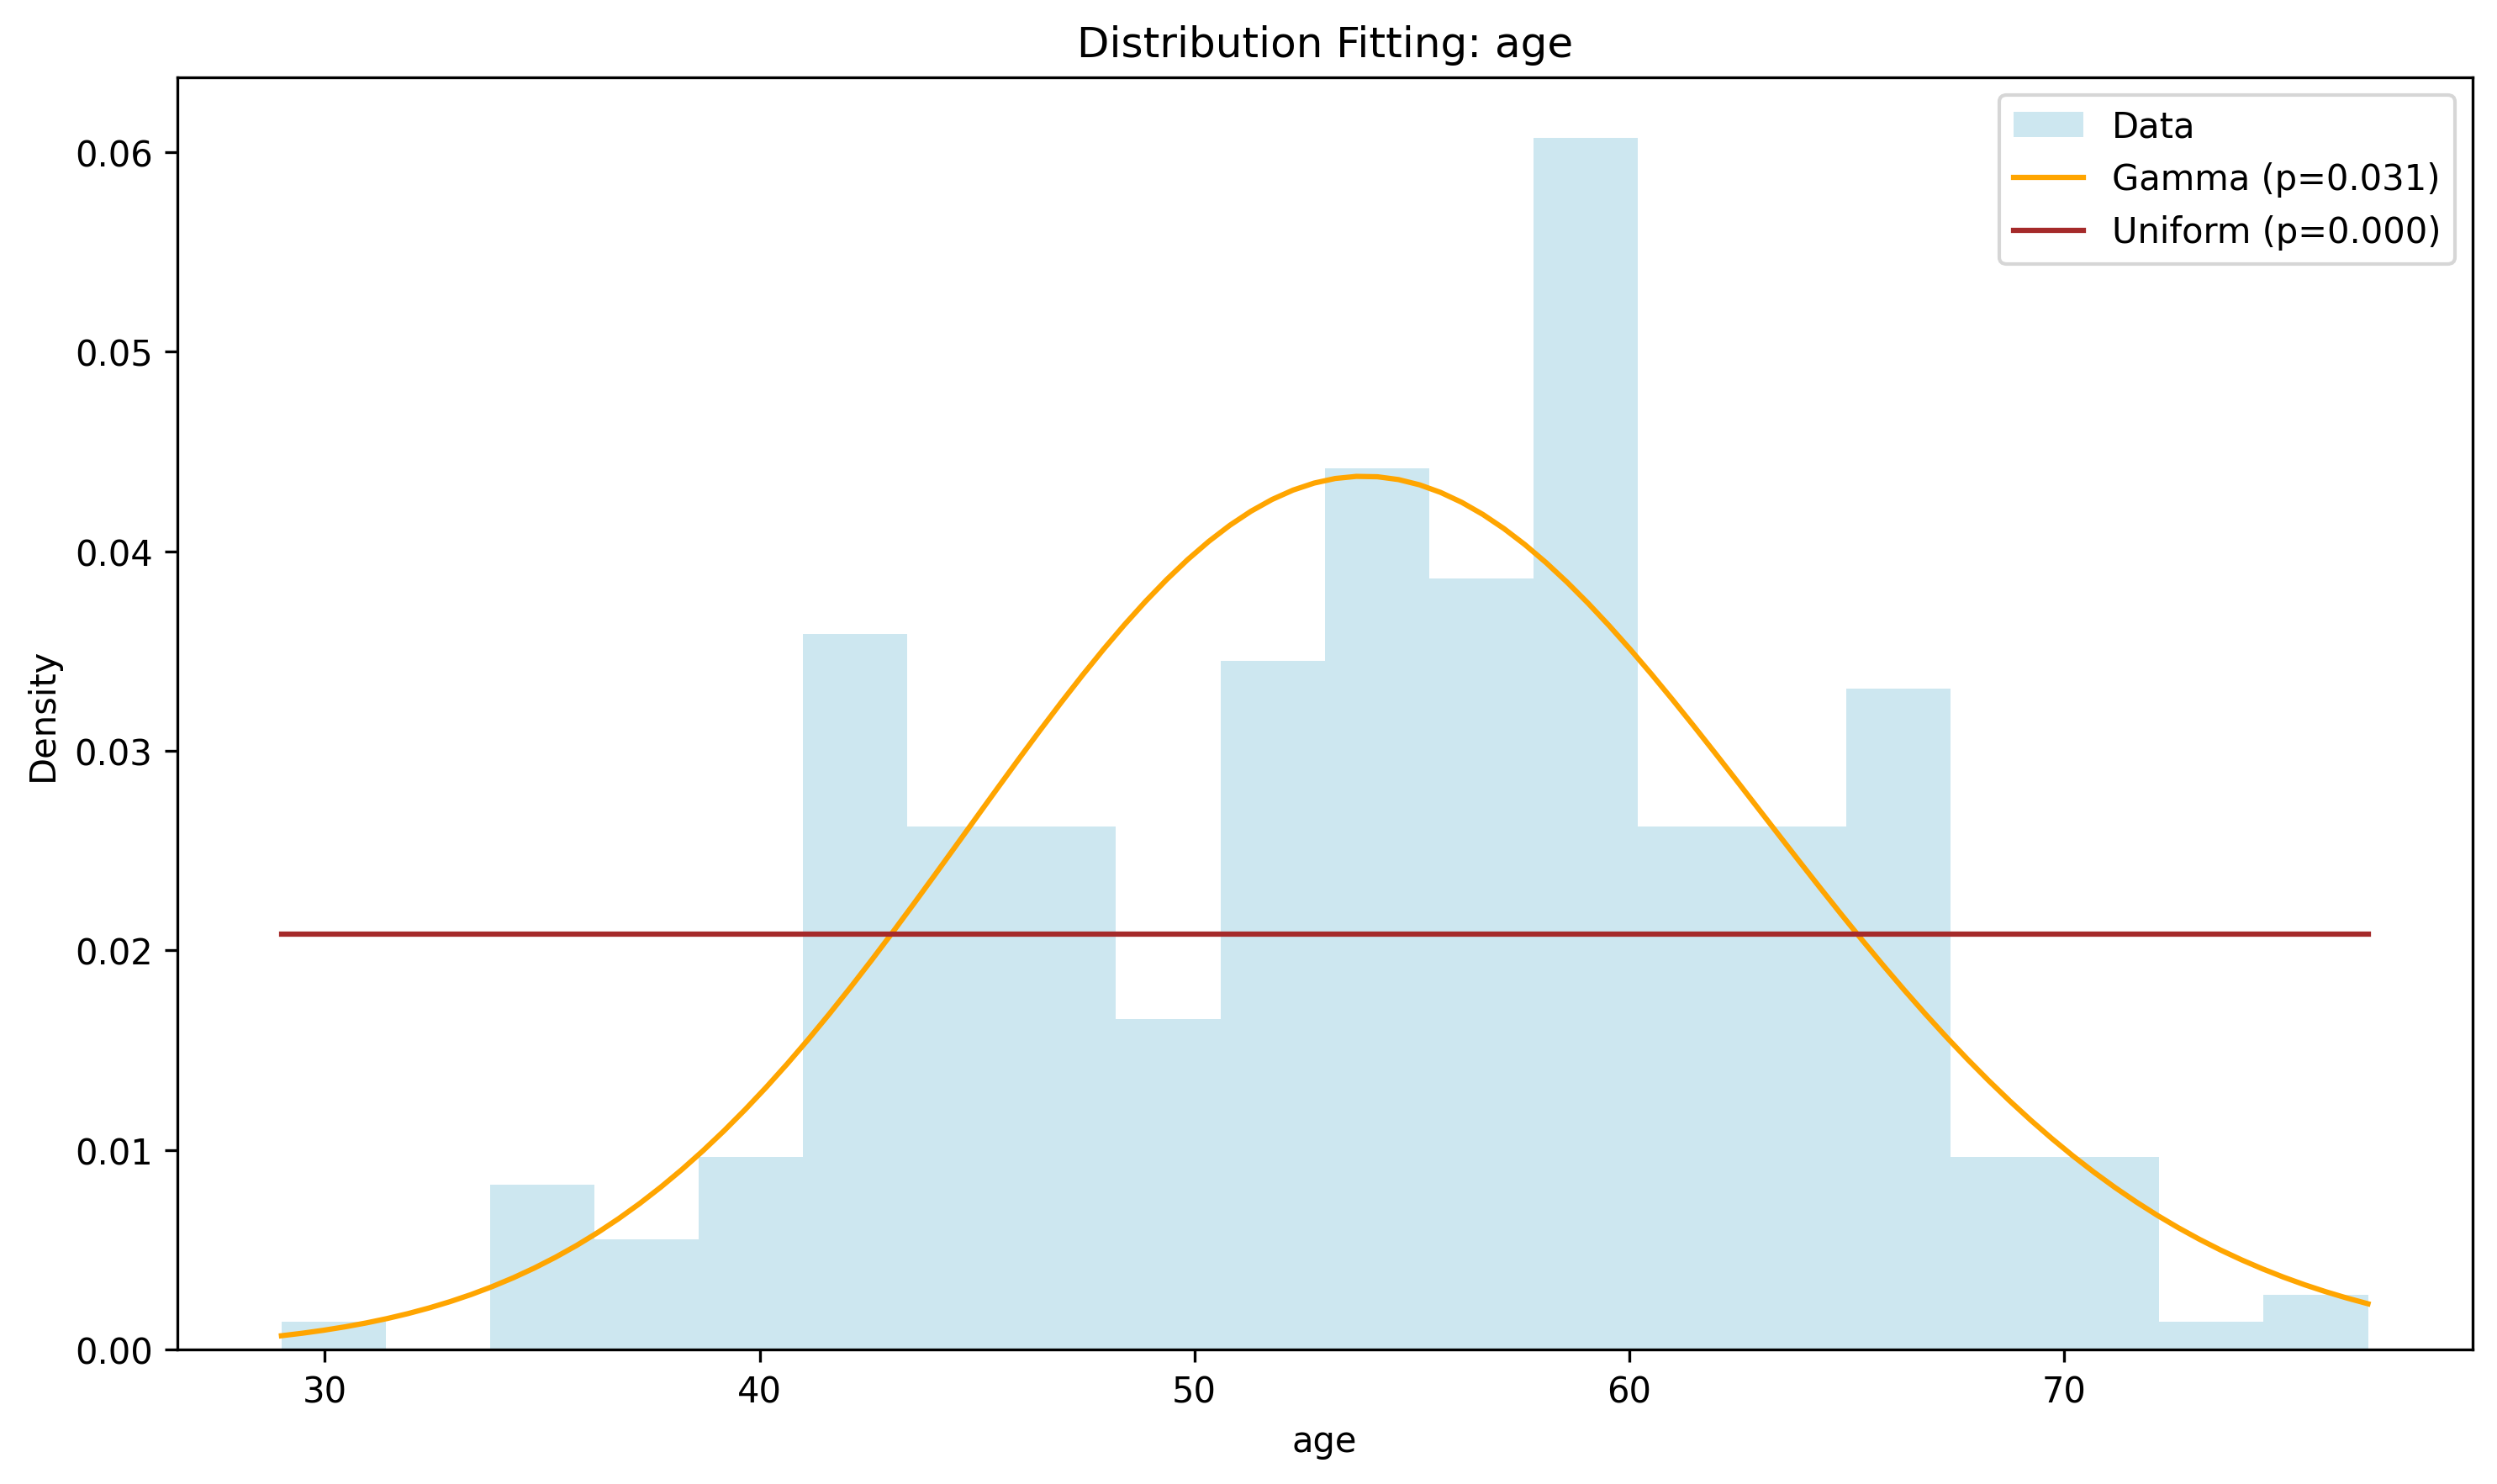

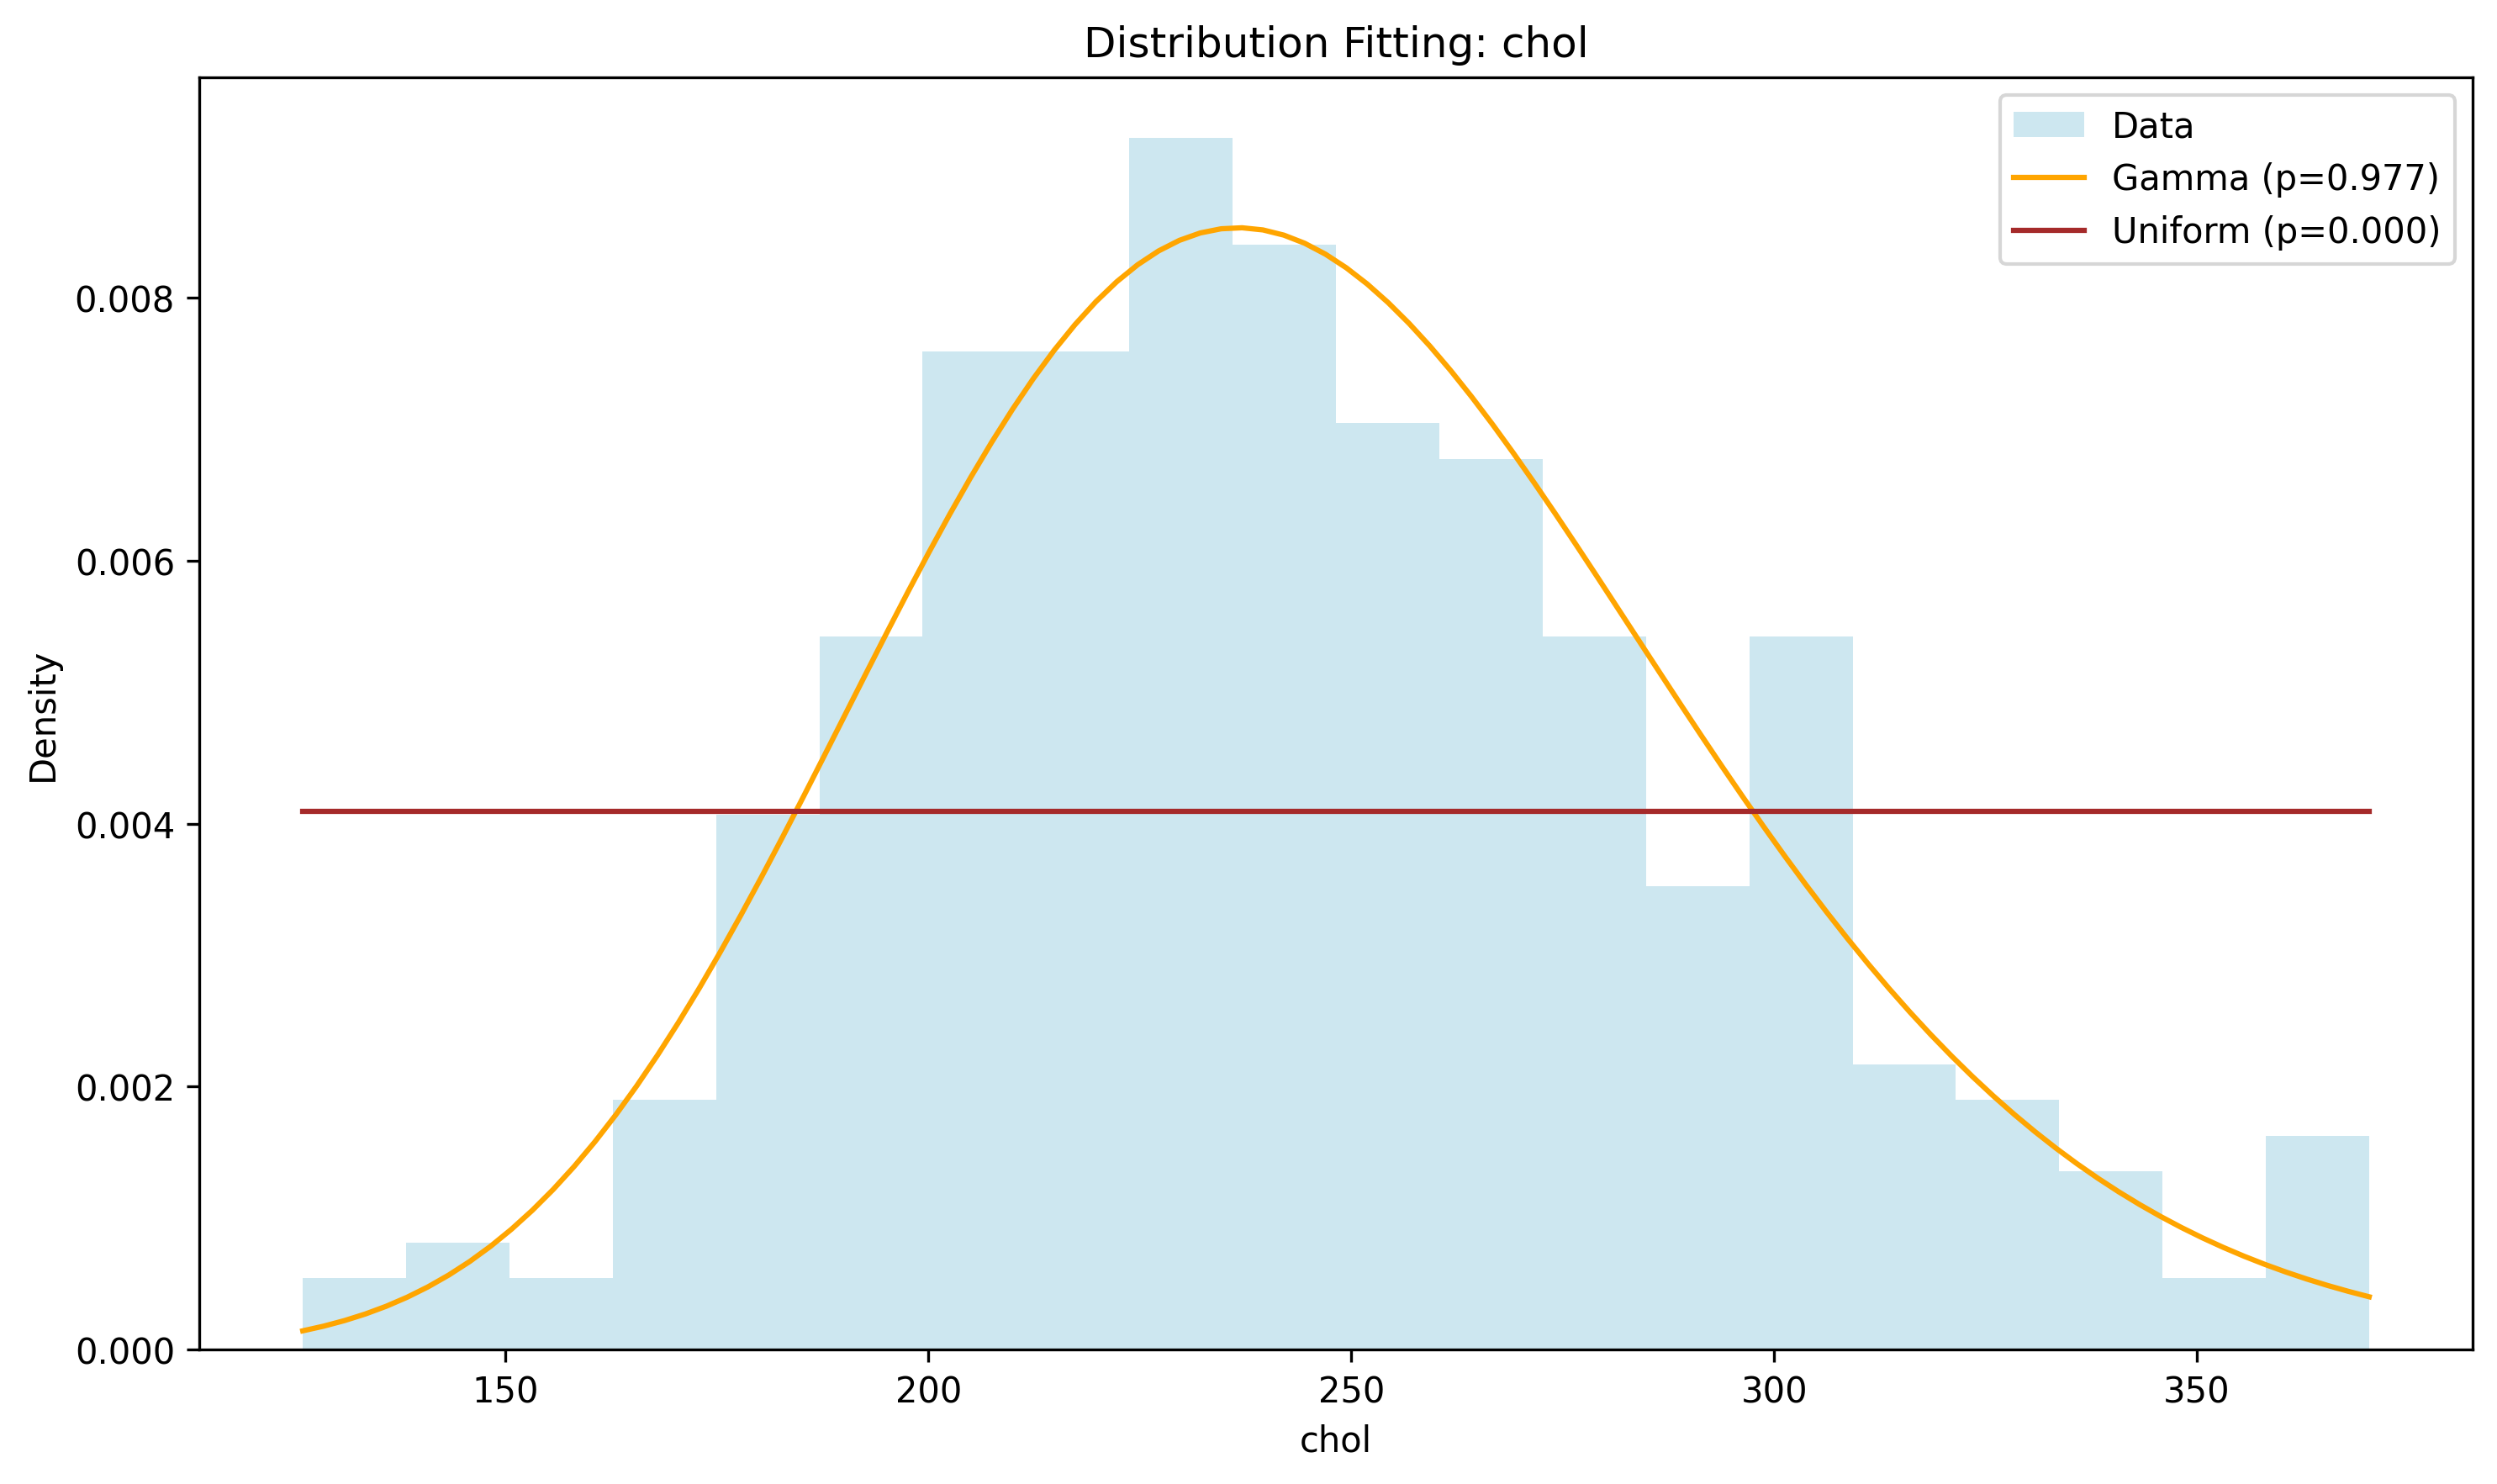

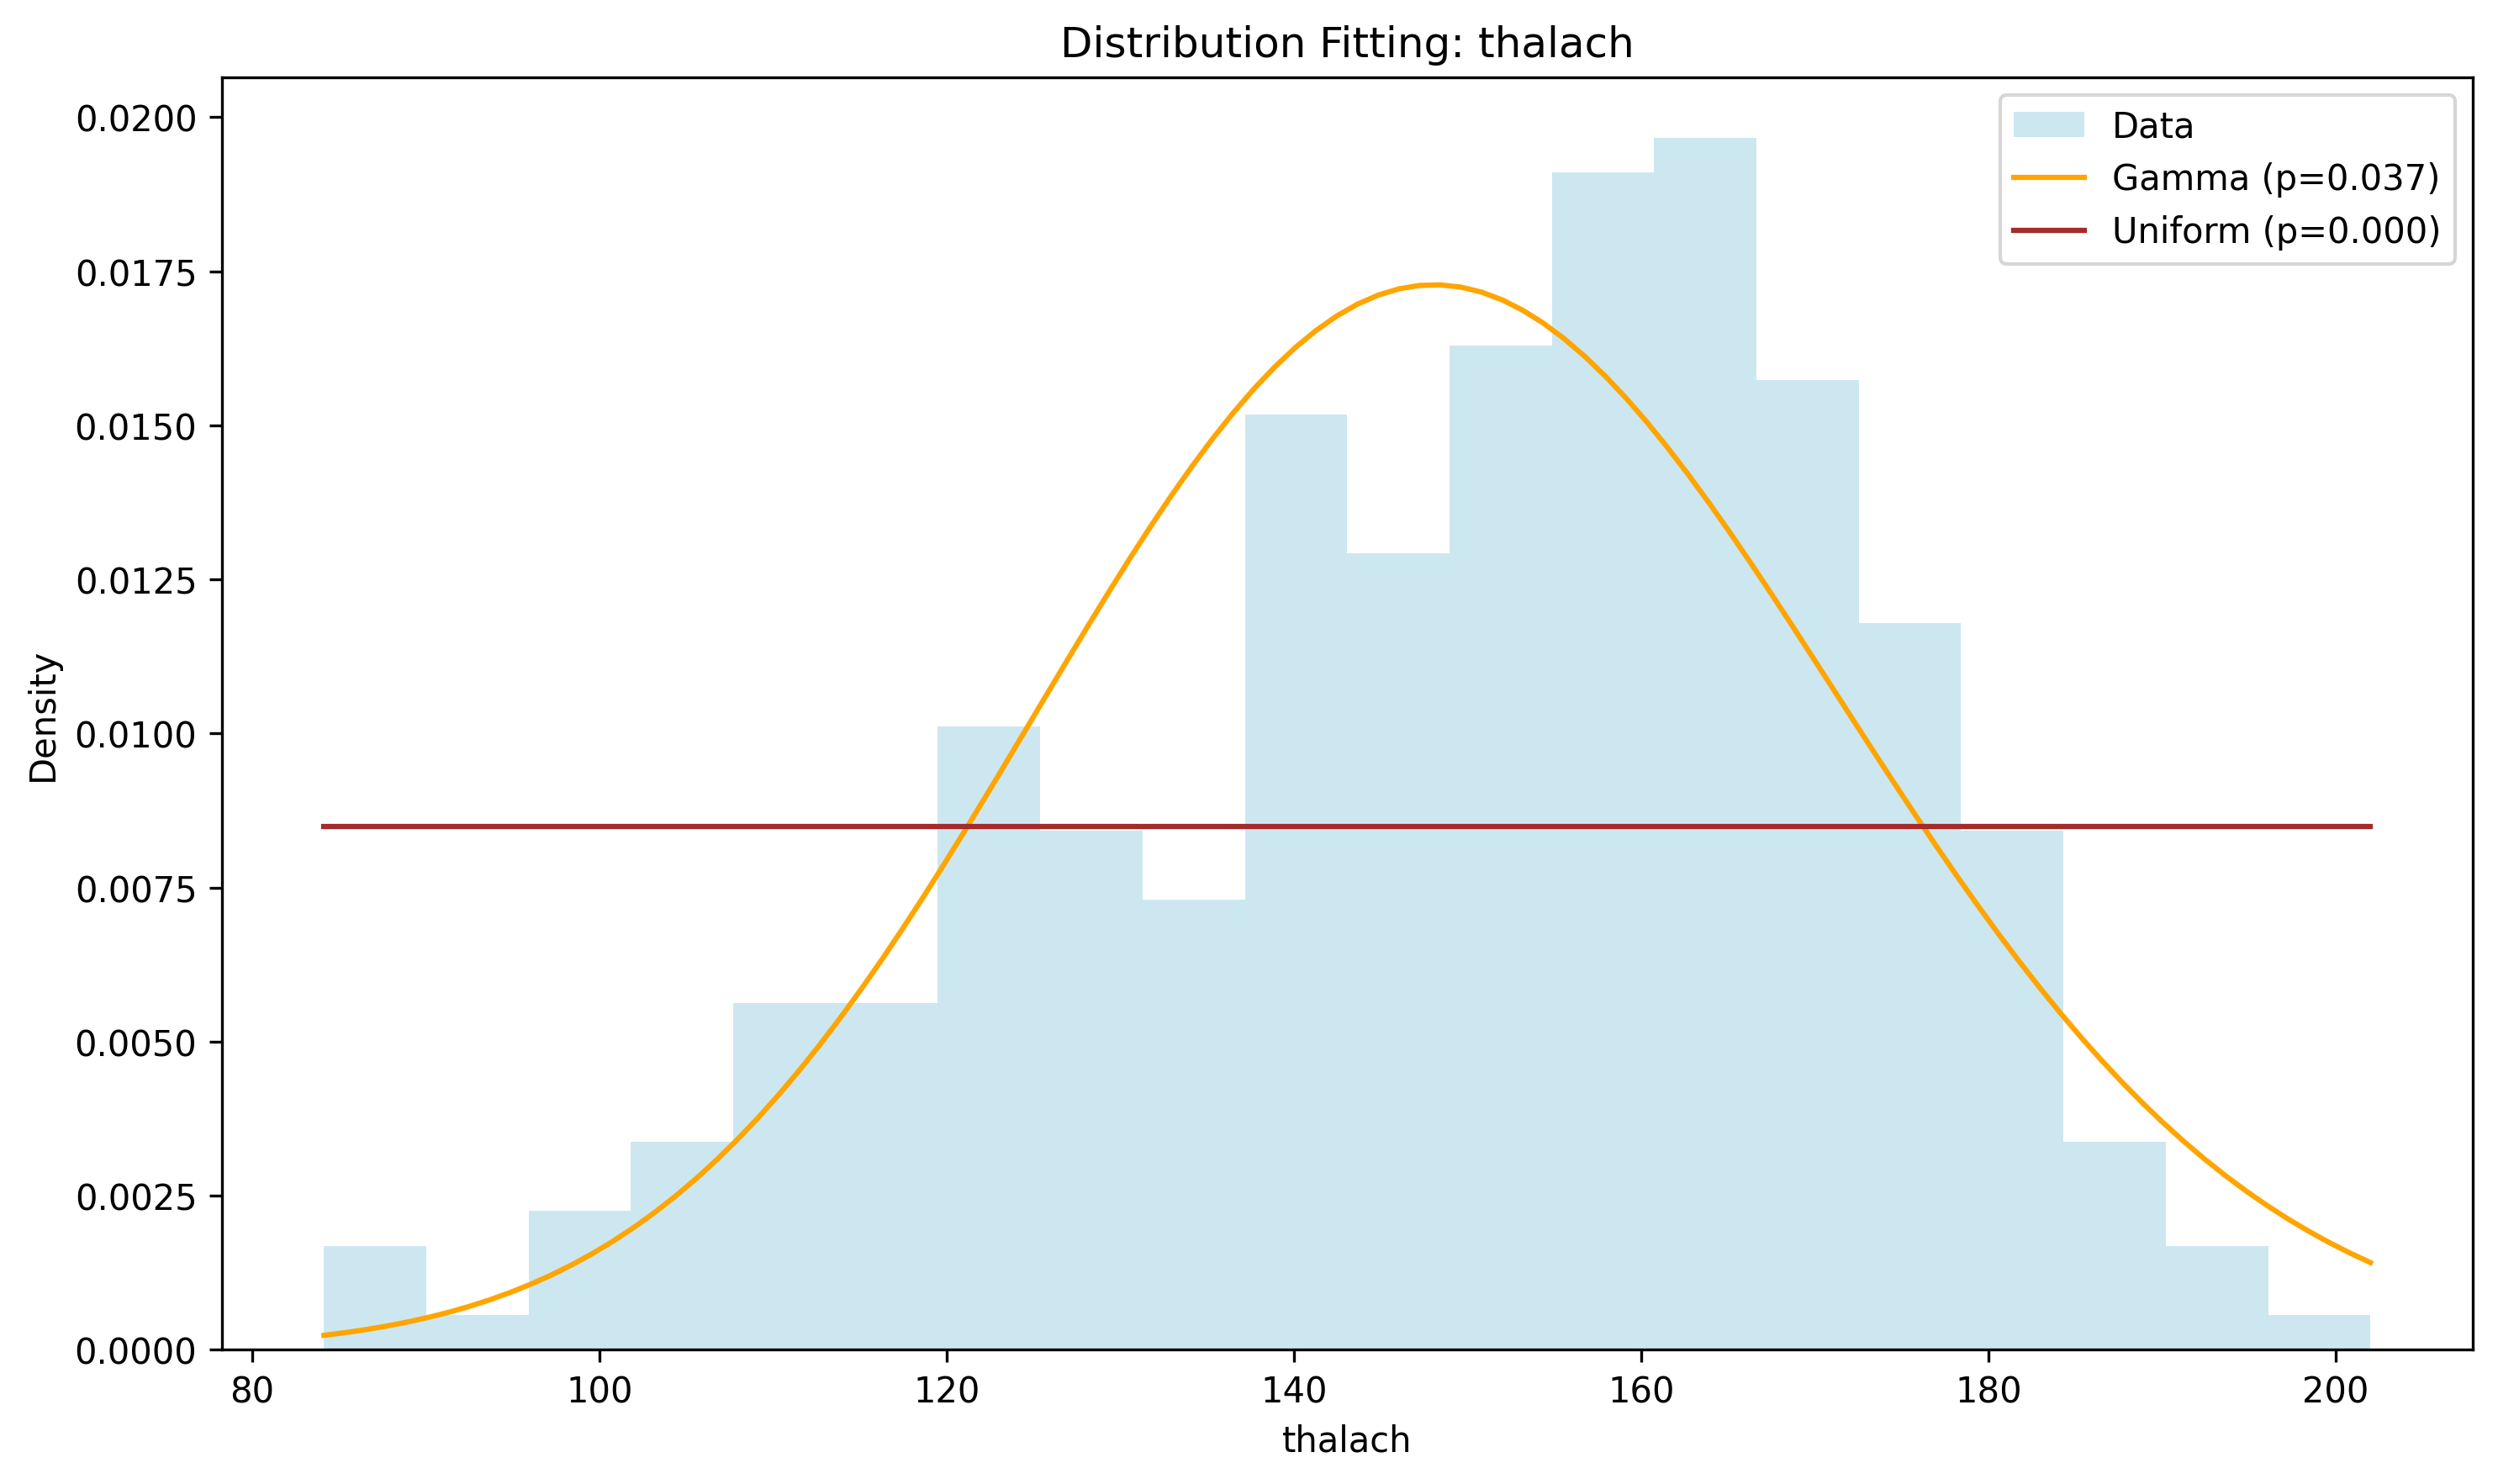

In [3]:
# ================= 2. VISUALIZE FITTED DISTRIBUTIONS ==================
def plot_fitted_distributions(df, column, results):
    """Plot histogram with fitted distributions."""
    data = df[column].dropna()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(data, bins=20, density=True, alpha=0.6, color='lightblue', label='Data')

    colors = ['red', 'green', 'orange', 'purple', 'brown']
    for idx, (dist_name, result) in enumerate(results.items()):
        if 'params' in result:
            dist = getattr(stats, dist_name.lower())
            x = np.linspace(data.min(), data.max(), 100)
            try:
                pdf = dist.pdf(x, *result['params'])
                ax.plot(x, pdf, color=colors[idx % len(colors)],
                        label=f"{dist_name} (p={result['p_value']:.3f})")
            except Exception:
                pass

    ax.set_title(f'Distribution Fitting: {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'../reports/figures/distribution_fit_{column}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot for the clinically-relevant continuous columns
for col in ['age', 'chol', 'thalach']:
    if col in all_fitting_results:
        plot_fitted_distributions(df, col, all_fitting_results[col]['results'])

In [4]:
# ================== 3. CREATE DISTRIBUTION SUMMARY ==================
distribution_summary = []
for col, info in all_fitting_results.items():
    distribution_summary.append({
        'column': col,
        'best_fit': info['best_fit'],
        'p_value': info['best_p_value'],
        'good_fit': info['best_p_value'] > 0.05
    })

summary_df = pd.DataFrame(distribution_summary)
summary_df.to_csv('../reports/distribution_fitting_summary.csv', index=False)
print(summary_df.to_string())
print("\nDistribution fitting results saved to 'reports/distribution_fitting_summary.csv'")

           column best_fit       p_value  good_fit
0             age    Gamma  3.098917e-02     False
1        trestbps    Gamma  1.545688e-01      True
2            chol    Gamma  9.773469e-01      True
3         thalach    Gamma  3.709887e-02     False
4         oldpeak  Uniform  1.105214e-34     False
5      hr_reserve    Gamma  3.870910e-01      True
6  chol_age_ratio    Gamma  7.942181e-01      True

Distribution fitting results saved to 'reports/distribution_fitting_summary.csv'